# 🎬 Scene Detector Baseline

A modular, **inference-only** pipeline for automatic *scene* segmentation of video, built on top of
pretrained multimodal models. No training happens in this notebook — the goal is to produce a strong,
well-instrumented baseline (shots → multimodal shot embeddings → similarity-based scene grouping) that
can later be used as input to a supervised scene-boundary learner.



## 1. Environment Setup

We install every dependency needed by the pipeline:

- **TransNetV2** — pretrained deep-learning shot-boundary detector (`transnetv2-pytorch`, weights ship
  inside the pip package itself — no external checkpoint download required).
- **OpenCLIP** — pretrained visual embeddings.
- **CLAP** (via Hugging Face `transformers`, `laion/clap-htsat-unfused`) — pretrained audio embeddings.
- **Whisper** — pretrained speech-to-text.
- **SentenceTransformers** — pretrained text embeddings.
- **OpenCV / NumPy / pandas / matplotlib / scikit-learn** — general video/data utilities.

In [49]:
# ---------------------------------------------------------------------------
# 1.1 Core Python / data-science dependencies
# ---------------------------------------------------------------------------

import sys

!{sys.executable} -m pip install -q --upgrade pip
!{sys.executable} -m pip install -q opencv-python-headless matplotlib tqdm ffmpeg-python moviepy soundfile pandas

In [9]:
# ---------------------------------------------------------------------------
# 1.2 Pretrained-model libraries
# ---------------------------------------------------------------------------

import importlib

# TransNetV2 -> shot boundary detection (weights ship inside the pip package)
!pip install -q transnetv2-pytorch

# OpenCLIP -> visual embeddings
!pip install -q open_clip_torch

# transformers -> also provides the pretrained CLAP model/processor used for
# audio embeddings in Section 6 (laion/clap-htsat-unfused)
!pip install -q "transformers>=4.41,<5"

# Whisper -> speech transcription
!pip install -q openai-whisper

# SentenceTransformers -> text embeddings
!pip install -q sentence-transformers

# Torch safety net: only install if genuinely missing (leave Colab's existing,
# GPU-matched torch build alone otherwise).
try:
    importlib.import_module("torch")
    print("torch already available -- leaving the existing (GPU-matched) install in place.")
except ImportError:
    print("torch not found -- installing a CPU/CUDA-generic build as a fallback.")
    !pip install -q torch torchvision torchaudio

torch already available -- leaving the existing (GPU-matched) install in place.


In [10]:
# ---------------------------------------------------------------------------
# 1.3 TransNetV2 - pretrained shot boundary detector
# ---------------------------------------------------------------------------
# Package: https://pypi.org/project/transnetv2-pytorch/
# (PyTorch reimplementation of TransNetV2: Soucek & Lokoc, 2020,
#  https://arxiv.org/abs/2008.04838)

import traceback

TRANSNETV2_AVAILABLE = False
transnetv2_model = None

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

try:
    from transnetv2_pytorch import TransNetV2
    transnetv2_model = TransNetV2(device=DEVICE)
    TRANSNETV2_AVAILABLE = True
except Exception:
    traceback.print_exc()
    TRANSNETV2_AVAILABLE = False

print(f"TransNetV2 available: {TRANSNETV2_AVAILABLE}")
if not TRANSNETV2_AVAILABLE:
    print(
        "TransNetV2 could not be loaded. The pipeline will automatically fall "
        "back to a lightweight histogram-based shot detector in Section 3."
    )


TransNetV2 available: True


In [11]:
# ---------------------------------------------------------------------------
# 1.4 System tools (ffmpeg is required to slice per-shot audio clips)
# ---------------------------------------------------------------------------
!apt-get -qq update && apt-get -qq install -y ffmpeg > /dev/null


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [12]:
# ---------------------------------------------------------------------------
# 1.5 CUDA / GPU detection
# ---------------------------------------------------------------------------
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device      : {torch.cuda.get_device_name(0)}")
print(f"Using device    : {DEVICE}")


PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU device      : Tesla T4
Using device    : cuda


In [13]:
# ---------------------------------------------------------------------------
# 1.6 Common imports used throughout the notebook
# ---------------------------------------------------------------------------
import json
import shutil
import tempfile
import subprocess
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import List, Optional, Tuple, Dict, Any

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.metrics.pairwise import cosine_similarity

WORKDIR = Path("/content/scene_detector_workspace")
FRAMES_DIR = WORKDIR / "frames"
AUDIO_DIR = WORKDIR / "audio_shots"
OUTPUT_DIR = WORKDIR / "outputs"
for d in (WORKDIR, FRAMES_DIR, AUDIO_DIR, OUTPUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Workspace ready at:", WORKDIR)


Workspace ready at: /content/scene_detector_workspace


## 2. Input Video

Provide a video in one of three ways, chosen via `INPUT_METHOD` below:

- `"upload"` — pick a file through the Colab upload widget.
- `"path"` — point to a video you already have available; fill in `LOCAL_VIDEO_PATH`.
- `"download"` — no video handy? Automatically fetch a short, freely-licensed sample clip so the
  whole pipeline can be exercised end-to-end with zero setup.

Whichever method is used, the notebook resolves everything to a single `VIDEO_PATH` variable that the
rest of the pipeline consumes — no other cell needs to know where the file actually lives.

In [16]:
# ---------------------------------------------------------------------------
# 2.1 Choose input method
# ---------------------------------------------------------------------------
INPUT_METHOD = "download"   # one of: "upload", "path", "download"
LOCAL_VIDEO_PATH = ""       # only used when INPUT_METHOD == "path" -- set to your own video's path

import os  # FIX: this cell needs os.path / os.path.getsize directly -- don't
           # rely on another cell having imported it first.

# Sintel trailer (Blender Foundation, CC-BY 3.0) -- ~52s, fast-cut trailer
# with dozens of distinct shots/scenes.
SAMPLE_VIDEO_URLS = [
    "https://download.blender.org/durian/trailer/sintel_trailer-720p.mp4",
]

import urllib.request

def download_sample_video(urls, dest_path):
    """Try each candidate URL in turn; report download progress."""
    last_err = None
    for url in urls:
        try:
            print(f"Trying: {url}")
            request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(request, timeout=120) as response:
                total = int(response.headers.get("Content-Length", 0))
                downloaded = 0
                chunk_size = 1024 * 1024  # 1MB
                with open(dest_path, "wb") as out_file:
                    while True:
                        chunk = response.read(chunk_size)
                        if not chunk:
                            break
                        out_file.write(chunk)
                        downloaded += len(chunk)
                        if total:
                            print(f"\r  {downloaded / 1e6:.1f} / {total / 1e6:.1f} MB", end="")
                print()
            if os.path.getsize(dest_path) == 0:
                raise RuntimeError("Downloaded file is empty.")
            return dest_path
        except Exception as e:
            last_err = e
            print(f"  Failed ({e}) -- trying next mirror.")
    raise RuntimeError(f"All download URLs failed. Last error: {last_err}")


VIDEO_PATH = None

if INPUT_METHOD == "upload":
    try:
        from google.colab import files  # only available on Colab
        print("Please choose a video file to upload...")
        uploaded = files.upload()
        if uploaded:
            uploaded_name = next(iter(uploaded.keys()))
            VIDEO_PATH = str(WORKDIR / uploaded_name)
            shutil.move(uploaded_name, VIDEO_PATH)
        else:
            raise RuntimeError("No file was uploaded.")
    except ImportError:
        print("Not running on Colab -- falling back to downloading a sample video instead.")
        INPUT_METHOD = "download"
    except Exception:
        traceback.print_exc()
        print("Upload failed -- falling back to downloading a sample video instead.")
        INPUT_METHOD = "download"

if INPUT_METHOD == "path":
    assert LOCAL_VIDEO_PATH, "Set LOCAL_VIDEO_PATH to the video you want to use."
    VIDEO_PATH = LOCAL_VIDEO_PATH

if INPUT_METHOD == "download":
    dest = WORKDIR / "sample_video.mp4"
    # Re-download if a previous run left a 0-byte / suspiciously tiny file
    # behind (e.g. an interrupted download) instead of silently reusing it.
    if not dest.exists() or dest.stat().st_size < 1_000_000:
        print("Downloading Sintel trailer (~7MB, ~52s, many scenes)...")
        download_sample_video(SAMPLE_VIDEO_URLS, dest)
    VIDEO_PATH = str(dest)

assert VIDEO_PATH and os.path.isfile(VIDEO_PATH), (
    "No usable video was found -- check INPUT_METHOD / LOCAL_VIDEO_PATH."
)
print(f"Using video (method={INPUT_METHOD}):", VIDEO_PATH)


Trying: https://download.blender.org/durian/trailer/sintel_trailer-720p.mp4
  7.6 / 7.6 MB
Using video (method=download): /content/scene_detector_workspace/sample_video.mp4


In [18]:
# ---------------------------------------------------------------------------
# 2.2 Video metadata (duration, fps, total frames)
# ---------------------------------------------------------------------------
def get_video_metadata(video_path):
    """Read basic metadata from a video file using OpenCV."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    duration = total_frames / fps if fps > 0 else 0.0
    cap.release()

    return {
        "path": video_path,
        "fps": fps,
        "total_frames": total_frames,
        "width": width,
        "height": height,
        "duration_sec": duration,
    }


VIDEO_META = get_video_metadata(VIDEO_PATH)
print(f"Duration      : {VIDEO_META['duration_sec']:.2f} s")
print(f"FPS           : {VIDEO_META['fps']:.3f}")
print(f"Total frames  : {VIDEO_META['total_frames']}")
print(f"Resolution    : {VIDEO_META['width']}x{VIDEO_META['height']}")


Duration      : 52.21 s
FPS           : 24.000
Total frames  : 1253
Resolution    : 1280x720


## 3. Shot Detection

We detect **shots** — contiguous camera takes with no cut — using the pretrained **TransNetV2**
shot-boundary-detection CNN. `run_transnetv2()` calls `model.detect_scenes(video_path)`, which returns
each shot's frame range directly in-process (no result files to parse, no subprocess).

If TransNetV2 is unavailable (install failed, corrupted environment, etc.) we automatically fall back to
`histogram_shot_detector()` — a dependency-free, content-aware shot detector based on HSV-histogram
differences between consecutive frames. This keeps the notebook fully runnable end-to-end either way.

Every shot is represented by a simple `Shot` dataclass: `shot_id`, `start_frame`, `end_frame`, `duration`.

In [19]:
# ---------------------------------------------------------------------------
# 3.1 Shot data structure
# ---------------------------------------------------------------------------
@dataclass
class Shot:
    shot_id: int
    start_frame: int
    end_frame: int
    fps: float

    @property
    def duration(self):
        """Shot duration in seconds."""
        return (self.end_frame - self.start_frame + 1) / self.fps if self.fps > 0 else 0.0

    @property
    def start_time(self):
        return self.start_frame / self.fps if self.fps > 0 else 0.0

    @property
    def end_time(self):
        return self.end_frame / self.fps if self.fps > 0 else 0.0

    def to_dict(self):
        return {
            "shot_id": self.shot_id,
            "start_frame": self.start_frame,
            "end_frame": self.end_frame,
            "start_time": round(self.start_time, 3),
            "end_time": round(self.end_time, 3),
            "duration": round(self.duration, 3),
        }


In [20]:
# ---------------------------------------------------------------------------
# 3.2 TransNetV2 wrapper (primary shot detector)
# ---------------------------------------------------------------------------
#   for t in [0.30, 0.35, 0.40, 0.45]:
#       shots = run_transnetv2(video_path, fps, threshold=t)
#       print(t, len(shots))
TRANSNETV2_THRESHOLD = 0.35

def run_transnetv2(video_path, fps, threshold=TRANSNETV2_THRESHOLD):
    """Run the pretrained TransNetV2 model on video_path and return shots.

    model.detect_scenes(...) returns a list of dicts with 'start_frame' /
    'end_frame' (already 0-indexed, inclusive) -- no result files to parse.
    """
    scenes = transnetv2_model.detect_scenes(video_path, threshold=threshold)
    shots = [
        Shot(shot_id=i, start_frame=int(sc["start_frame"]), end_frame=int(sc["end_frame"]), fps=fps)
        for i, sc in enumerate(scenes)
    ]
    return shots

In [21]:
# ---------------------------------------------------------------------------
# 3.3 Fallback: dependency-free histogram-based shot detector
# ---------------------------------------------------------------------------
def histogram_shot_detector(video_path, fps, threshold=0.6, min_shot_len_frames=8):
    """Content-aware shot detector using HSV histogram correlation between
    consecutive frames. A shot boundary is declared whenever the histogram
    correlation drops below `threshold` (i.e. the frames look very different).

    This is a simple, well-understood, dependency-free baseline used only when
    the pretrained TransNetV2 model is unavailable.
    """
    cap = cv2.VideoCapture(video_path)
    prev_hist = None
    boundaries = [0]
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist([hsv], [0, 1], None, [50, 60], [0, 180, 0, 256])
        cv2.normalize(hist, hist)

        if prev_hist is not None:
            corr = cv2.compareHist(prev_hist, hist, cv2.HISTCMP_CORREL)
            if corr < threshold and (frame_idx - boundaries[-1]) >= min_shot_len_frames:
                boundaries.append(frame_idx)
        prev_hist = hist
        frame_idx += 1
    cap.release()

    total_frames = frame_idx
    boundaries.append(total_frames - 1)
    boundaries = sorted(set(boundaries))

    shots = []
    for i in range(len(boundaries) - 1):
        start = boundaries[i] if i == 0 else boundaries[i] + 1
        end = boundaries[i + 1]
        if end <= start:
            continue
        shots.append(Shot(shot_id=len(shots), start_frame=start, end_frame=end, fps=fps))
    return shots


In [22]:
# ---------------------------------------------------------------------------
# 3.4 Run shot detection (TransNetV2 with automatic fallback) + micro-shot merge
# ---------------------------------------------------------------------------
MIN_PLAUSIBLE_SHOT_RATE = 1 / 30   # at least 1 shot per 30s of video
MAX_PLAUSIBLE_SHOT_RATE = 8        # at most 8 shots per second of video

def shots_look_plausible(shots, duration_sec):
    if not shots or duration_sec <= 0:
        return False
    rate = len(shots) / duration_sec
    return MIN_PLAUSIBLE_SHOT_RATE <= rate <= MAX_PLAUSIBLE_SHOT_RATE


def detect_shots(video_path, fps, duration_sec):
    """Detect shots, preferring TransNetV2 and falling back gracefully."""
    if TRANSNETV2_AVAILABLE:
        try:
            shots = run_transnetv2(video_path, fps)
            if shots and shots_look_plausible(shots, duration_sec):
                return shots, "TransNetV2"
            print(f"TransNetV2 returned {len(shots)} shots for a {duration_sec:.1f}s video -- "
                  "this looks implausible (possibly uninitialized/mismatched weights). "
                  "Falling back to histogram detector.")
        except Exception:
            traceback.print_exc()
            print("TransNetV2 inference failed -- falling back to histogram detector.")

    shots = histogram_shot_detector(video_path, fps)
    return shots, "HistogramFallback"


# Merge micro-shots (flash frames, detector jitter) into the preceding
# shot. A run of several sub-second "shots" in a row is almost always a
# detector artifact rather than real editing, and it inflates the shot count
# in a way that hurts every downstream step (frame sampling, embeddings,
# scene grouping all get noisier).
MIN_SHOT_DURATION = 0.7  # seconds

def merge_micro_shots(shots, min_duration):
    if not shots:
        return shots
    merged = [shots[0]]
    for shot in shots[1:]:
        if shot.duration < min_duration and merged:
            prev = merged[-1]
            merged[-1] = Shot(shot_id=prev.shot_id, start_frame=prev.start_frame,
                               end_frame=shot.end_frame, fps=prev.fps)
        else:
            merged.append(shot)
    # renumber shot_ids to stay contiguous after merging
    return [Shot(shot_id=i, start_frame=s.start_frame, end_frame=s.end_frame, fps=s.fps)
            for i, s in enumerate(merged)]


_raw_shots, SHOT_DETECTOR_USED = detect_shots(VIDEO_PATH, VIDEO_META["fps"], VIDEO_META["duration_sec"])
SHOTS = merge_micro_shots(_raw_shots, MIN_SHOT_DURATION)

print(f"Detector used   : {SHOT_DETECTOR_USED}")
print(f"Shots (raw)     : {len(_raw_shots)}")
print(f"Shots (merged)  : {len(SHOTS)}  (min_shot_duration={MIN_SHOT_DURATION}s)")

shots_df = pd.DataFrame([s.to_dict() for s in SHOTS])
shots_df.head(10)

Detector used   : TransNetV2
Shots (raw)     : 18
Shots (merged)  : 16  (min_shot_duration=0.7s)


,shot_id,start_frame,end_frame,start_time,end_time,duration
0,0,0,120,0.000,5.000,5.042
1,1,121,206,5.042,8.583,3.583
2,2,209,291,8.708,12.125,3.458
3,3,295,333,12.292,13.875,1.625
4,4,334,395,13.917,16.458,2.583
5,5,396,419,16.500,17.458,1.000
6,6,420,503,17.500,20.958,3.500
7,7,505,535,21.042,22.292,1.292
8,8,539,570,22.458,23.750,1.333
9,9,571,620,23.792,25.833,2.083


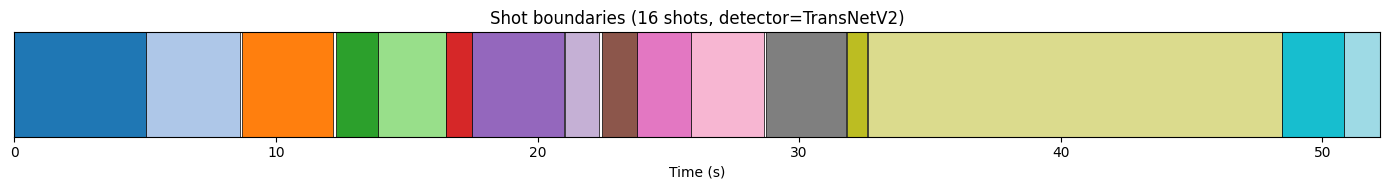

In [23]:
# ---------------------------------------------------------------------------
# 3.5 Visualize shot boundaries on a timeline
# ---------------------------------------------------------------------------
def plot_shot_timeline(shots, duration):
    fig, ax = plt.subplots(figsize=(14, 2))
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(shots), 1)))
    for shot, color in zip(shots, colors):
        ax.add_patch(Rectangle((shot.start_time, 0), shot.duration, 1, color=color, ec="black", lw=0.5))
    ax.set_xlim(0, duration)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("Time (s)")
    ax.set_title(f"Shot boundaries ({len(shots)} shots, detector={SHOT_DETECTOR_USED})")
    plt.tight_layout()
    plt.show()


plot_shot_timeline(SHOTS, VIDEO_META["duration_sec"])


## 4. Representative Frame Extraction

previously only 3 frames (first/middle/last) were sampled per shot. That's often not
enough to capture a shot's visual content, especially with camera movement (pans, zooms, handheld
motion) or action -- a shot can look quite different at 10% vs 90% of its duration even with no cut.

We now sample **16 frames per shot, uniformly** across the shot's duration (0%-100%) instead of the
shot's duration, and average all 8 OpenCLIP embeddings in Section 5. This is more compute per shot
but meaningfully more robust, and shot counts are typically in the tens-to-low-hundreds so the cost
stays modest.

In [24]:
# ---------------------------------------------------------------------------
# 4.1 Frame-reading utilities
# ---------------------------------------------------------------------------
# Sample 8 frames uniformly across the shot instead of just first/middle/last.
FRAME_SAMPLE_FRACTIONS = [round(f, 4) for f in np.linspace(0.0, 1.0, 16)]  # 16 uniform samples/shot (was 8)

def frame_sample_name(frac):
    return f"p{int(round(frac * 100))}"


def read_frame_at(video_path, frame_idx):
    """Read a single frame (BGR) at frame_idx from a video."""
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    return frame if ret else None


def shot_sample_frame_indices(shot, fractions=FRAME_SAMPLE_FRACTIONS):
    """Map fractional positions (0.0-1.0) within a shot to concrete frame indices."""
    span = shot.end_frame - shot.start_frame
    return {
        frame_sample_name(frac): shot.start_frame + int(round(frac * span))
        for frac in fractions
    }


def extract_representative_frames(video_path, shot):
    """Extract uniformly-sampled frames (as RGB arrays) for a shot."""
    frame_indices = shot_sample_frame_indices(shot)
    frames = {}
    for name, idx in frame_indices.items():
        frame_bgr = read_frame_at(video_path, idx)
        if frame_bgr is not None:
            frames[name] = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    return frames

Extracted representative frames for 16 shots (16 samples/shot).


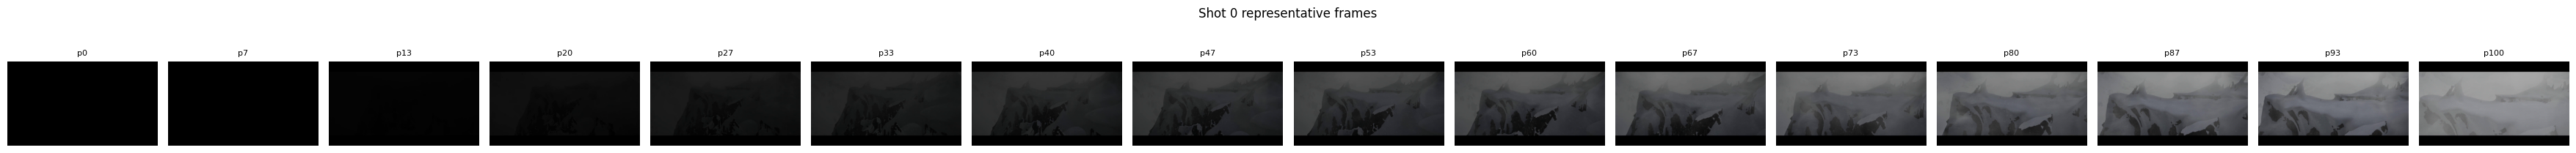

In [25]:
# ---------------------------------------------------------------------------
# 4.2 Extract and cache representative frames for every shot (single video pass)
# ---------------------------------------------------------------------------
# To minimize duplicate computation we open the video ONCE and grab every frame
# we need (FRAME_SAMPLE_FRACTIONS per shot) in a single sequential pass rather
# than re-seeking per shot.
def extract_all_representative_frames(video_path, shots):
    wanted_frames = {}
    for shot in shots:
        for name, idx in shot_sample_frame_indices(shot).items():
            wanted_frames.setdefault(idx, []).append((shot.shot_id, name))

    result = {shot.shot_id: {} for shot in shots}

    cap = cv2.VideoCapture(video_path)
    frame_idx = 0
    max_wanted = max(wanted_frames.keys()) if wanted_frames else -1
    while frame_idx <= max_wanted:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx in wanted_frames:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            for shot_id, name in wanted_frames[frame_idx]:
                result[shot_id][name] = rgb
        frame_idx += 1
    cap.release()
    return result


REP_FRAMES = extract_all_representative_frames(VIDEO_PATH, SHOTS)
print(f"Extracted representative frames for {len(REP_FRAMES)} shots "
      f"({len(FRAME_SAMPLE_FRACTIONS)} samples/shot).")

# Quick sanity check: show all sampled frames of the first shot
if SHOTS:
    names = [frame_sample_name(f) for f in FRAME_SAMPLE_FRACTIONS]
    fig, axes = plt.subplots(1, len(names), figsize=(2.2 * len(names), 2.4))
    for ax, name in zip(axes, names):
        frame = REP_FRAMES[SHOTS[0].shot_id].get(name)
        if frame is not None:
            ax.imshow(frame)
        ax.set_title(name, fontsize=8)
        ax.axis("off")
    plt.suptitle(f"Shot {SHOTS[0].shot_id} representative frames")
    plt.tight_layout()
    plt.show()


## 5. Visual Embeddings (OpenCLIP)

We load a pretrained **OpenCLIP** `ViT-B-32` model (`laion2b_s34b_b79k` weights) and embed each
representative frame. The three per-shot frame embeddings (first/middle/last) are averaged and
L2-normalized to obtain a single **visual embedding per shot**, which captures both the shot's static
content and any intra-shot visual change.

In [26]:
# ---------------------------------------------------------------------------
# 5.1 Load pretrained OpenCLIP model
# ---------------------------------------------------------------------------
import open_clip
from PIL import Image
import traceback

CLIP_MODEL_NAME = "ViT-B-32"
CLIP_PRETRAINED = "laion2b_s34b_b79k"

CLIP_AVAILABLE = False
clip_model, clip_preprocess = None, None
VISUAL_EMBED_DIM = 512  # ViT-B-32 default; overwritten below if the model loads successfully

try:
    clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
        CLIP_MODEL_NAME, pretrained=CLIP_PRETRAINED
    )
    clip_model = clip_model.to(DEVICE).eval()
    VISUAL_EMBED_DIM = clip_model.visual.output_dim
    CLIP_AVAILABLE = True
    print(f"Loaded OpenCLIP {CLIP_MODEL_NAME} ({CLIP_PRETRAINED}) -> embedding dim {VISUAL_EMBED_DIM}")
except Exception:
    traceback.print_exc()
    print(f"OpenCLIP failed to load -- visual embeddings will fall back to zero vectors (dim={VISUAL_EMBED_DIM}).")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loaded OpenCLIP ViT-B-32 (laion2b_s34b_b79k) -> embedding dim 512


In [27]:
# ---------------------------------------------------------------------------
# 5.2 Embed a single frame with OpenCLIP
# ---------------------------------------------------------------------------
@torch.no_grad()
def embed_frame_clip(frame_rgb):
    """Return an L2-normalized OpenCLIP embedding for a single RGB frame."""
    image = Image.fromarray(frame_rgb)
    tensor = clip_preprocess(image).unsqueeze(0).to(DEVICE)
    feats = clip_model.encode_image(tensor)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.squeeze(0).float().cpu().numpy()


def compute_shot_visual_embedding(rep_frames):
    """Average the first/middle/last frame embeddings, then re-normalize.
    Falls back to a zero vector if OpenCLIP is unavailable.
    """
    if not CLIP_AVAILABLE:
        return np.zeros(VISUAL_EMBED_DIM, dtype=np.float32)

    embeds = [embed_frame_clip(f) for f in rep_frames.values() if f is not None]
    if not embeds:
        return np.zeros(VISUAL_EMBED_DIM, dtype=np.float32)
    avg = np.mean(embeds, axis=0)
    norm = np.linalg.norm(avg)
    return (avg / norm if norm > 0 else avg).astype(np.float32)


In [28]:
# ---------------------------------------------------------------------------
# 5.3 Compute visual embeddings for every shot
# ---------------------------------------------------------------------------
VISUAL_EMBEDDINGS = {}
for shot in SHOTS:
    VISUAL_EMBEDDINGS[shot.shot_id] = compute_shot_visual_embedding(REP_FRAMES[shot.shot_id])

print(f"Computed visual embeddings for {len(VISUAL_EMBEDDINGS)} shots "
      f"(dim={VISUAL_EMBED_DIM}).")


Computed visual embeddings for 16 shots (dim=512).


## 6. Audio Embeddings (CLAP)

For every shot we slice out the corresponding audio segment with `ffmpeg`, then embed it with the
pretrained **CLAP** (Contrastive Language-Audio Pretraining) model `laion/clap-htsat-unfused`. Shots with
no audio track, a silent/empty clip, or any extraction failure gracefully fall back to a **zero vector**
of the correct dimensionality so downstream fusion never breaks.

In [29]:
# ---------------------------------------------------------------------------
# 6.1 Load pretrained CLAP model (via transformers, not the laion-clap package)
# ---------------------------------------------------------------------------
from transformers import ClapModel, ClapProcessor

CLAP_MODEL_ID = "laion/clap-htsat-unfused"
CLAP_SAMPLE_RATE = 48000  # required input sample rate for this CLAP checkpoint

CLAP_AVAILABLE = False
clap_model, clap_processor = None, None
AUDIO_EMBED_DIM = 512  # ClapModel's default projection dim; overwritten below on success

try:
    clap_processor = ClapProcessor.from_pretrained(CLAP_MODEL_ID)
    clap_model = ClapModel.from_pretrained(CLAP_MODEL_ID).to(DEVICE).eval()

    # Infer the audio embedding dimensionality with a short silent dummy clip.
    _dummy_audio = np.zeros(CLAP_SAMPLE_RATE, dtype=np.float32)  # 1s of silence @ 48kHz
    with torch.no_grad():
        _dummy_inputs = clap_processor(
            audios=[_dummy_audio], sampling_rate=CLAP_SAMPLE_RATE, return_tensors="pt"
        ).to(DEVICE)
        _dummy_embed = clap_model.get_audio_features(**_dummy_inputs)
    AUDIO_EMBED_DIM = int(_dummy_embed.shape[-1])
    CLAP_AVAILABLE = True
    print(f"Loaded CLAP ({CLAP_MODEL_ID}) via transformers -> embedding dim {AUDIO_EMBED_DIM}")
except Exception:
    traceback.print_exc()
    print(f"CLAP failed to load -- audio embeddings will fall back to zero vectors (dim={AUDIO_EMBED_DIM}).")


preprocessor_config.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/615M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/614M [00:00<?, ?B/s]

/tmp/ipykernel_815/1550205233.py:20: FutureWarning: `audios` is deprecated and will be removed in version v4.59.0 for `ClapProcessor.__call__`. Use `audio` instead.
  _dummy_inputs = clap_processor(


Loaded CLAP (laion/clap-htsat-unfused) via transformers -> embedding dim 512


In [30]:
# ---------------------------------------------------------------------------
# 6.2 Extract per-shot audio with ffmpeg
# ---------------------------------------------------------------------------
def extract_shot_audio(video_path, shot, out_dir, sr=CLAP_SAMPLE_RATE):
    """Extract the audio segment for a shot as a mono WAV file. Returns None on
    failure (e.g. the source video has no audio stream).
    """
    out_path = out_dir / f"shot_{shot.shot_id:04d}.wav"
    cmd = [
        "ffmpeg", "-y", "-loglevel", "error",
        "-i", video_path,
        "-ss", f"{shot.start_time:.3f}",
        "-to", f"{shot.end_time:.3f}",
        "-vn", "-ac", "1", "-ar", str(sr),
        str(out_path),
    ]
    proc = subprocess.run(cmd, capture_output=True)
    if proc.returncode != 0 or not out_path.exists() or out_path.stat().st_size == 0:
        return None
    return out_path


In [31]:
# ---------------------------------------------------------------------------
# 6.3 Embed per-shot audio with CLAP (with graceful silence/no-audio handling)
# ---------------------------------------------------------------------------
import soundfile as sf

@torch.no_grad()
def compute_shot_audio_embedding(video_path, shot):
    """Return an L2-normalized CLAP embedding for a shot's audio, or a zero
    vector if the shot has no usable audio track or CLAP failed to load.
    """
    if not CLAP_AVAILABLE:
        return np.zeros(AUDIO_EMBED_DIM, dtype=np.float32)

    wav_path = extract_shot_audio(video_path, shot, AUDIO_DIR)
    if wav_path is None:
        return np.zeros(AUDIO_EMBED_DIM, dtype=np.float32)

    try:
        audio, sr = sf.read(str(wav_path), dtype="float32")
        if audio.ndim > 1:  # safety: ensure mono
            audio = audio.mean(axis=1)
        if audio.size == 0 or np.allclose(audio, 0.0):
            return np.zeros(AUDIO_EMBED_DIM, dtype=np.float32)

        inputs = clap_processor(
            audios=[audio], sampling_rate=CLAP_SAMPLE_RATE, return_tensors="pt"
        ).to(DEVICE)
        embed = clap_model.get_audio_features(**inputs)
        embed = embed.squeeze(0).float().cpu().numpy()
        norm = np.linalg.norm(embed)
        return embed / norm if norm > 0 else embed
    except Exception:
        traceback.print_exc()
        return np.zeros(AUDIO_EMBED_DIM, dtype=np.float32)


In [32]:
# ---------------------------------------------------------------------------
# 6.4 Compute audio embeddings for every shot
# ---------------------------------------------------------------------------
AUDIO_EMBEDDINGS = {}
for shot in SHOTS:
    AUDIO_EMBEDDINGS[shot.shot_id] = compute_shot_audio_embedding(VIDEO_PATH, shot)

n_silent = sum(1 for e in AUDIO_EMBEDDINGS.values() if np.allclose(e, 0.0))
print(f"Computed audio embeddings for {len(AUDIO_EMBEDDINGS)} shots "
      f"(dim={AUDIO_EMBED_DIM}); {n_silent} shots had no usable audio.")


/tmp/ipykernel_815/3347001098.py:25: FutureWarning: `audios` is deprecated and will be removed in version v4.59.0 for `ClapProcessor.__call__`. Use `audio` instead.
  inputs = clap_processor(
/tmp/ipykernel_815/3347001098.py:25: FutureWarning: `audios` is deprecated and will be removed in version v4.59.0 for `ClapProcessor.__call__`. Use `audio` instead.
  inputs = clap_processor(
/tmp/ipykernel_815/3347001098.py:25: FutureWarning: `audios` is deprecated and will be removed in version v4.59.0 for `ClapProcessor.__call__`. Use `audio` instead.
  inputs = clap_processor(
/tmp/ipykernel_815/3347001098.py:25: FutureWarning: `audios` is deprecated and will be removed in version v4.59.0 for `ClapProcessor.__call__`. Use `audio` instead.
  inputs = clap_processor(
/tmp/ipykernel_815/3347001098.py:25: FutureWarning: `audios` is deprecated and will be removed in version v4.59.0 for `ClapProcessor.__call__`. Use `audio` instead.
  inputs = clap_processor(
/tmp/ipykernel_815/3347001098.py:25: Fut

Computed audio embeddings for 16 shots (dim=512); 0 shots had no usable audio.


/tmp/ipykernel_815/3347001098.py:25: FutureWarning: `audios` is deprecated and will be removed in version v4.59.0 for `ClapProcessor.__call__`. Use `audio` instead.
  inputs = clap_processor(


## 7. Speech Embeddings (Whisper + SentenceTransformers)

We reuse the per-shot audio clips extracted in Section 6, transcribe them with a pretrained
**Whisper** model, and encode the resulting transcript with a pretrained **SentenceTransformer**
(`all-MiniLM-L6-v2`). Shots with no speech (empty transcript, no audio, transcription failure) fall
back to a **zero vector** of the correct dimensionality, exactly like the audio branch.

In [33]:
# ---------------------------------------------------------------------------
# 7.1 Load pretrained Whisper + SentenceTransformer models
# ---------------------------------------------------------------------------
import whisper
from sentence_transformers import SentenceTransformer

WHISPER_MODEL_SIZE = "base"  # good speed/accuracy trade-off for a baseline

WHISPER_AVAILABLE = False
whisper_model = None
try:
    whisper_model = whisper.load_model(WHISPER_MODEL_SIZE, device=DEVICE)
    WHISPER_AVAILABLE = True
    print(f"Loaded Whisper ({WHISPER_MODEL_SIZE}).")
except Exception:
    traceback.print_exc()
    print("Whisper failed to load -- transcripts will be empty for every shot.")

SBERT_AVAILABLE = False
sbert_model = None
TEXT_EMBED_DIM = 384  # all-MiniLM-L6-v2's dim; overwritten below on success
try:
    sbert_model = SentenceTransformer("all-MiniLM-L6-v2", device=DEVICE)
    TEXT_EMBED_DIM = sbert_model.get_sentence_embedding_dimension()
    SBERT_AVAILABLE = True
    print(f"Loaded SentenceTransformer -> text embedding dim {TEXT_EMBED_DIM}")
except Exception:
    traceback.print_exc()
    print(f"SentenceTransformer failed to load -- text embeddings will fall back to zero vectors (dim={TEXT_EMBED_DIM}).")


100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 134MiB/s]


Loaded Whisper (base).


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded SentenceTransformer -> text embedding dim 384


/tmp/ipykernel_815/3721331576.py:24: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  TEXT_EMBED_DIM = sbert_model.get_sentence_embedding_dimension()


In [34]:
# ---------------------------------------------------------------------------
# 7.2 Transcribe + encode a shot's audio
# ---------------------------------------------------------------------------
def transcribe_shot_audio(wav_path):
    """Transcribe a WAV file with Whisper. Returns '' if no audio, Whisper is
    unavailable, or transcription fails."""
    if not WHISPER_AVAILABLE or wav_path is None or not wav_path.exists():
        return ""
    try:
        result = whisper_model.transcribe(str(wav_path), fp16=(DEVICE == "cuda"))
        return result.get("text", "").strip()
    except Exception:
        traceback.print_exc()
        return ""


@torch.no_grad()
def compute_shot_text_embedding(transcript):
    """Encode a transcript with SentenceTransformers; zero vector if empty or
    if SentenceTransformers is unavailable."""
    if not transcript or not SBERT_AVAILABLE:
        return np.zeros(TEXT_EMBED_DIM, dtype=np.float32)
    embed = sbert_model.encode(transcript, normalize_embeddings=True)
    return np.asarray(embed, dtype=np.float32)


In [35]:
# ---------------------------------------------------------------------------
# 7.3 Compute transcripts + text embeddings for every shot
# ---------------------------------------------------------------------------
# We reuse the WAV files already extracted for CLAP in Section 6 to avoid
# duplicate ffmpeg calls.
TRANSCRIPTS = {}
TEXT_EMBEDDINGS = {}

for shot in SHOTS:
    wav_path = AUDIO_DIR / f"shot_{shot.shot_id:04d}.wav"
    wav_path = wav_path if wav_path.exists() else None
    transcript = transcribe_shot_audio(wav_path)
    TRANSCRIPTS[shot.shot_id] = transcript
    TEXT_EMBEDDINGS[shot.shot_id] = compute_shot_text_embedding(transcript)

n_with_speech = sum(1 for t in TRANSCRIPTS.values() if t)
print(f"Transcribed {len(TRANSCRIPTS)} shots; {n_with_speech} contained detectable speech "
      f"(text embedding dim={TEXT_EMBED_DIM}).")


Transcribed 16 shots; 4 contained detectable speech (text embedding dim=384).


## 8. Feature Fusion

Each shot's visual, audio, and text embeddings are combined into one **fused embedding** and
L2-normalized. All fused embeddings and their metadata are persisted as structured artifacts
(`embeddings.npy` + `metadata.csv`) -- no plain-text dumps.

In [36]:
# ---------------------------------------------------------------------------
# 8.1 Fuse visual + audio + text embeddings per shot (reweighted)
# ---------------------------------------------------------------------------
# Explicit modality weights before concatenation. Visual dominates (0.70)
# since it's the most reliable and always-present signal for scene continuity;
# audio/text support it but shouldn't be able to outweigh it just because they
# have similar vector norms after L2-normalization.
MODALITY_WEIGHTS = {"visual": 0.70, "audio": 0.15, "text": 0.15}

def fuse_embedding(visual, audio, text, weights=MODALITY_WEIGHTS):
    """Weight, concatenate, and re-normalize (L2) visual/audio/text embeddings."""
    weighted = [
        weights["visual"] * visual,
        weights["audio"] * audio,
        weights["text"] * text,
    ]
    fused = np.concatenate(weighted).astype(np.float32)
    norm = np.linalg.norm(fused)
    return fused / norm if norm > 0 else fused


FUSED_EMBEDDINGS = {}
for shot in SHOTS:
    FUSED_EMBEDDINGS[shot.shot_id] = fuse_embedding(
        VISUAL_EMBEDDINGS[shot.shot_id],
        AUDIO_EMBEDDINGS[shot.shot_id],
        TEXT_EMBEDDINGS[shot.shot_id],
    )

FUSED_DIM = VISUAL_EMBED_DIM + AUDIO_EMBED_DIM + TEXT_EMBED_DIM
print(f"Fused embedding dim: {FUSED_DIM} "
      f"(visual={VISUAL_EMBED_DIM} + audio={AUDIO_EMBED_DIM} + text={TEXT_EMBED_DIM})")
print(f"Modality weights: {MODALITY_WEIGHTS}")

Fused embedding dim: 1408 (visual=512 + audio=512 + text=384)
Modality weights: {'visual': 0.7, 'audio': 0.15, 'text': 0.15}


In [37]:
# ---------------------------------------------------------------------------
# 8.2 Persist embeddings + metadata to disk (structured formats only)
# ---------------------------------------------------------------------------
shot_ids_sorted = sorted(FUSED_EMBEDDINGS.keys())
embedding_matrix = np.stack([FUSED_EMBEDDINGS[sid] for sid in shot_ids_sorted]).astype(np.float32)

EMBEDDINGS_PATH = OUTPUT_DIR / "embeddings.npy"
np.save(EMBEDDINGS_PATH, embedding_matrix)

metadata_records = []
shots_by_id = {s.shot_id: s for s in SHOTS}
for row_idx, sid in enumerate(shot_ids_sorted):
    shot = shots_by_id[sid]
    metadata_records.append({
        "row_index": row_idx,
        "shot_id": sid,
        "start_frame": shot.start_frame,
        "end_frame": shot.end_frame,
        "start_time": round(shot.start_time, 3),
        "end_time": round(shot.end_time, 3),
        "duration": round(shot.duration, 3),
        "has_speech": bool(TRANSCRIPTS[sid]),
        "transcript": TRANSCRIPTS[sid],
        "visual_dim": VISUAL_EMBED_DIM,
        "audio_dim": AUDIO_EMBED_DIM,
        "text_dim": TEXT_EMBED_DIM,
        "fused_dim": FUSED_DIM,
    })

METADATA_PATH = OUTPUT_DIR / "metadata.csv"
metadata_df = pd.DataFrame(metadata_records)
metadata_df.to_csv(METADATA_PATH, index=False)

print(f"Saved embeddings -> {EMBEDDINGS_PATH}  (shape={embedding_matrix.shape})")
print(f"Saved metadata   -> {METADATA_PATH}")
metadata_df.head(10)


Saved embeddings -> /content/scene_detector_workspace/outputs/embeddings.npy  (shape=(16, 1408))
Saved metadata   -> /content/scene_detector_workspace/outputs/metadata.csv


,row_index,shot_id,start_frame,end_frame,start_time,end_time,duration,has_speech,transcript,visual_dim,audio_dim,text_dim,fused_dim
0,0,0,0,120,0.000,5.000,5.042,False,,512,512,384,1408
1,1,1,121,206,5.042,8.583,3.583,False,,512,512,384,1408
2,2,2,209,291,8.708,12.125,3.458,False,,512,512,384,1408
3,3,3,295,333,12.292,13.875,1.625,True,What brings you to the land of the gate?,512,512,384,1408
4,4,4,334,395,13.917,16.458,2.583,True,and keep your peace?,512,512,384,1408
5,5,5,396,419,16.500,17.458,1.000,False,,512,512,384,1408
6,6,6,420,503,17.500,20.958,3.500,True,I'm searching for someone.,512,512,384,1408
7,7,7,505,535,21.042,22.292,1.292,False,,512,512,384,1408
8,8,8,539,570,22.458,23.750,1.333,False,,512,512,384,1408
9,9,9,571,620,23.792,25.833,2.083,False,,512,512,384,1408


## 9. Scene Detection Baseline

the previous approach compared only shot *i* against shot *i+1*. That is a weak
signal, because many real scenes contain shot/reverse-shot conversations, alternating angles,
cutaways, and reaction shots -- adjacent shots can look very different even though they belong to
the same scene, and a single-pair comparison has no way to tell "a real scene change" apart from
"the camera cut to the other side of the same conversation."

This version replaces single-pair comparison with **windowed context similarity**, the same idea
behind common academic scene-boundary baselines:

```
left_context  = mean(embeddings of the previous WINDOW_SIZE shots)
right_context = mean(embeddings of the next WINDOW_SIZE shots)
boundary_score = cosine(left_context, right_context)
```

Averaging a few shots on each side smooths out the shot-to-shot noise that shot/reverse-shot editing
creates, so a boundary is only detected when the surrounding *context* actually changes, not just one
adjacent pair. Two grouping strategies are provided on top of this signal (pick via
`SCENE_GROUPING_METHOD` below):

- **`"windowed_threshold"`** -- an adaptive threshold on `boundary_score`, same mechanism as before
  but on the much stronger windowed signal, plus a minimum-scene-length merge pass.
- **`"clustering"`** -- contiguity-constrained agglomerative clustering directly on shot embeddings
  (cosine distance), keeping only *contiguous* runs of shots that share the same cluster label as one
  scene. This tends to produce cleaner boundaries than any single threshold rule, at the cost of one
  more hyperparameter (`distance_threshold`) to tune per source. I determined that the windowed_threshold is easier to interpret from this notebook, as we decided to go with clustering for the longer videos (movies), wheras it is better to experiment with windowed_threshold as well.

In [38]:
# ---------------------------------------------------------------------------
# 9.1 Windowed context similarity
# ---------------------------------------------------------------------------
# Replaces single-pair (shot i vs shot i+1) comparison. For every shot
# boundary we average WINDOW_SIZE shots on each side and compare the two
# context vectors, which is far more robust to shot/reverse-shot editing,
# cutaways, and reaction shots than a single adjacent pair ever can be.
WINDOW_SIZE = 3

def _safe_mean_normalize(vectors):
    """Mean of a list of embeddings, re-normalized; zero vector if input is empty/all-zero."""
    if not vectors:
        return None
    avg = np.mean(vectors, axis=0)
    norm = np.linalg.norm(avg)
    return avg / norm if norm > 0 else avg


def _safe_cosine(a, b):
    if a is None or b is None:
        return 0.0
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0.0 or nb == 0.0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))


def windowed_boundary_scores(shot_ids, fused_emb, window_size=WINDOW_SIZE):
    """boundary_score[i] = cosine(context before shot_ids[i+1], context after).
    Length = n_shots - 1, matching the previous consecutive-similarity shape
    so downstream plotting/grouping code doesn't need to change shape-wise.
    Window shrinks near the two ends of the shot list instead of padding.
    """
    n = len(shot_ids)
    if n < 2:
        return np.array([])

    scores = []
    for i in range(n - 1):
        left_ids = shot_ids[max(0, i - window_size + 1): i + 1]
        right_ids = shot_ids[i + 1: i + 1 + window_size]
        left_ctx = _safe_mean_normalize([fused_emb[sid] for sid in left_ids])
        right_ctx = _safe_mean_normalize([fused_emb[sid] for sid in right_ids])
        scores.append(_safe_cosine(left_ctx, right_ctx))
    return np.nan_to_num(np.array(scores), nan=0.0)


SIMILARITIES = windowed_boundary_scores(shot_ids_sorted, FUSED_EMBEDDINGS, WINDOW_SIZE)
if len(SIMILARITIES):
    print(f"Computed {len(SIMILARITIES)} windowed boundary scores (window_size={WINDOW_SIZE}) "
          f"(min={SIMILARITIES.min():.3f}, max={SIMILARITIES.max():.3f}, mean={SIMILARITIES.mean():.3f})")
else:
    print("Not enough shots to compute boundary scores.")

Computed 15 windowed boundary scores (window_size=3) (min=0.362, max=0.904, mean=0.753)


Using boundary-score threshold = 0.853 (adaptive, p85)


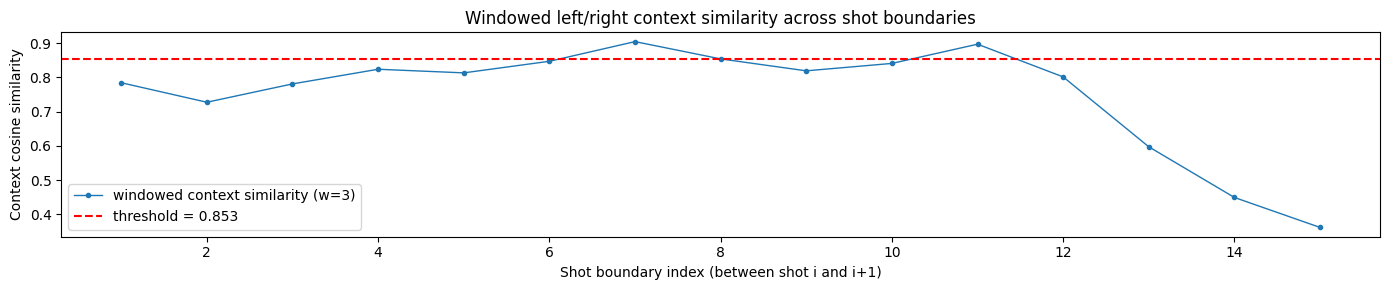

In [39]:
# ---------------------------------------------------------------------------
# 9.2 Adaptive threshold selection + boundary-score plot
# ---------------------------------------------------------------------------
# Threshold is derived from this video's own boundary-score distribution by
# default (scene cuts sit in the low tail), rather than a single fixed value
# tuned on a different video. Set USE_ADAPTIVE_THRESHOLD = False and
# FIXED_SIMILARITY_THRESHOLD to override.
USE_ADAPTIVE_THRESHOLD = True
ADAPTIVE_THRESHOLD_PERCENTILE = 85   # lower -> fewer, longer scenes; higher -> more, shorter scenes
FIXED_SIMILARITY_THRESHOLD = 0.75    # only used if USE_ADAPTIVE_THRESHOLD is False

def pick_similarity_threshold(similarities):
    if not USE_ADAPTIVE_THRESHOLD:
        return FIXED_SIMILARITY_THRESHOLD
    if len(similarities) == 0:
        return FIXED_SIMILARITY_THRESHOLD
    return float(np.percentile(similarities, ADAPTIVE_THRESHOLD_PERCENTILE))


SIMILARITY_THRESHOLD = pick_similarity_threshold(SIMILARITIES)
print(f"Using boundary-score threshold = {SIMILARITY_THRESHOLD:.3f} "
      f"({'adaptive, p' + str(ADAPTIVE_THRESHOLD_PERCENTILE) if USE_ADAPTIVE_THRESHOLD else 'fixed'})")


def plot_similarity_curve(similarities, threshold):
    fig, ax = plt.subplots(figsize=(14, 3))
    x = np.arange(1, len(similarities) + 1)
    ax.plot(x, similarities, marker="o", ms=3, lw=1, label=f"windowed context similarity (w={WINDOW_SIZE})")
    ax.axhline(threshold, color="red", ls="--", label=f"threshold = {threshold:.3f}")
    ax.set_xlabel("Shot boundary index (between shot i and i+1)")
    ax.set_ylabel("Context cosine similarity")
    ax.set_title("Windowed left/right context similarity across shot boundaries")
    ax.legend()
    plt.tight_layout()
    plt.show()


if len(SIMILARITIES):
    plot_similarity_curve(SIMILARITIES, SIMILARITY_THRESHOLD)


In [40]:
# ---------------------------------------------------------------------------
# 9.3 Scene grouping: windowed-threshold OR contiguity-constrained clustering
# ---------------------------------------------------------------------------
# Two selectable grouping strategies on top of the fused shot embeddings.
#   "windowed_threshold" -- threshold the windowed boundary score (9.1/9.2),
#                           then merge any scene shorter than MIN_SCENE_SHOTS.
#   "clustering"          -- AgglomerativeClustering (cosine, average linkage)
#                           over shot embeddings directly, then collapse to
#                           scenes by keeping only *contiguous* runs of shots
#                           that share a cluster label (non-contiguous shots
#                           sharing a cluster, e.g. two similar-looking but
#                           far-apart scenes, are NOT merged -- scenes must
#                           still be contiguous in time).
SCENE_GROUPING_METHOD = "windowed_threshold"  # "windowed_threshold" or "clustering"
MIN_SCENE_SHOTS = 2
CLUSTERING_DISTANCE_THRESHOLD = 0.45  # only used for "clustering"; higher -> fewer, larger clusters

from sklearn.cluster import AgglomerativeClustering


@dataclass
class Scene:
    scene_id: int
    shot_ids: List[int]

    def to_dict(self, shots_by_id):
        first_shot = shots_by_id[self.shot_ids[0]]
        last_shot = shots_by_id[self.shot_ids[-1]]
        return {
            "scene_id": self.scene_id,
            "shot_ids": self.shot_ids,
            "start_frame": first_shot.start_frame,
            "end_frame": last_shot.end_frame,
            "start_time": round(first_shot.start_time, 3),
            "end_time": round(last_shot.end_time, 3),
            "duration": round(last_shot.end_time - first_shot.start_time, 3),
        }


def group_by_windowed_threshold(shot_ids, similarities, threshold):
    """Start a new scene whenever the windowed boundary score drops below threshold."""
    if not shot_ids:
        return []
    groups = [[shot_ids[0]]]
    for i, sim in enumerate(similarities):
        next_shot_id = shot_ids[i + 1]
        if sim < threshold:
            groups.append([next_shot_id])
        else:
            groups[-1].append(next_shot_id)
    return groups


def group_by_contiguous_clustering(shot_ids, embedding_matrix, distance_threshold):
    """Cluster shot embeddings (cosine, average linkage), then split into
    scenes wherever the cluster label changes between consecutive shots --
    i.e. only contiguous same-cluster runs are merged into one scene.
    """
    if len(shot_ids) < 2:
        return [[sid] for sid in shot_ids]

    clusterer = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=distance_threshold,
        metric="cosine",
        linkage="average",
    )
    labels = clusterer.fit_predict(embedding_matrix)

    groups = [[shot_ids[0]]]
    for i in range(1, len(shot_ids)):
        if labels[i] == labels[i - 1]:
            groups[-1].append(shot_ids[i])
        else:
            groups.append([shot_ids[i]])
    return groups


def merge_short_groups(groups, similarities, shot_ids, min_shots):
    """Merge any group shorter than min_shots into its more-similar neighbor,
    using the boundary similarity computed in 9.1. Runs to a fixed point since
    a merge can leave a newly-adjacent pair still short.
    """
    if min_shots <= 1 or len(similarities) == 0:
        return groups

    sim_by_boundary = {shot_ids[i]: similarities[i] for i in range(len(similarities))}

    changed = True
    while changed and len(groups) > 1:
        changed = False
        for i, g in enumerate(groups):
            if len(g) >= min_shots:
                continue
            sim_prev = sim_by_boundary.get(groups[i - 1][-1], -1.0) if i > 0 else -1.0
            sim_next = sim_by_boundary.get(g[-1], -1.0) if i < len(groups) - 1 else -1.0
            if sim_prev < 0 and sim_next < 0:
                break
            if sim_next >= sim_prev:
                groups[i:i + 2] = [groups[i] + groups[i + 1]]
            else:
                groups[i - 1:i + 1] = [groups[i - 1] + groups[i]]
            changed = True
            break
    return groups


if SCENE_GROUPING_METHOD == "windowed_threshold":
    raw_groups = group_by_windowed_threshold(shot_ids_sorted, SIMILARITIES, SIMILARITY_THRESHOLD)
elif SCENE_GROUPING_METHOD == "clustering":
    raw_groups = group_by_contiguous_clustering(shot_ids_sorted, embedding_matrix, CLUSTERING_DISTANCE_THRESHOLD)
else:
    raise ValueError(f"Unknown SCENE_GROUPING_METHOD: {SCENE_GROUPING_METHOD}")

merged_groups = merge_short_groups(raw_groups, SIMILARITIES, shot_ids_sorted, MIN_SCENE_SHOTS)
SCENES = [Scene(scene_id=i, shot_ids=g) for i, g in enumerate(merged_groups)]

print(f"Method: {SCENE_GROUPING_METHOD}")
print(f"Detected {len(SCENES)} scenes from {len(SHOTS)} shots "
      f"(min_scene_shots={MIN_SCENE_SHOTS}, before merge={len(raw_groups)}):\n")
for scene in SCENES:
    lo, hi = scene.shot_ids[0], scene.shot_ids[-1]
    label = f"Shot {lo}" if lo == hi else f"Shots {lo}-{hi}"
    print(f"Scene {scene.scene_id + 1}:\n  {label}\n")

Method: windowed_threshold
Detected 4 scenes from 16 shots (min_scene_shots=2, before merge=4):

Scene 1:
  Shots 0-1

Scene 2:
  Shots 2-4

Scene 3:
  Shots 5-8

Scene 4:
  Shots 9-15



## 10. Visualization

We now combine everything into one view: **shot boundaries**, the **similarity curve**, and the
resulting **scene boundaries**, followed by a gallery of representative frames — one per detected
scene (using the middle frame of that scene's first shot).

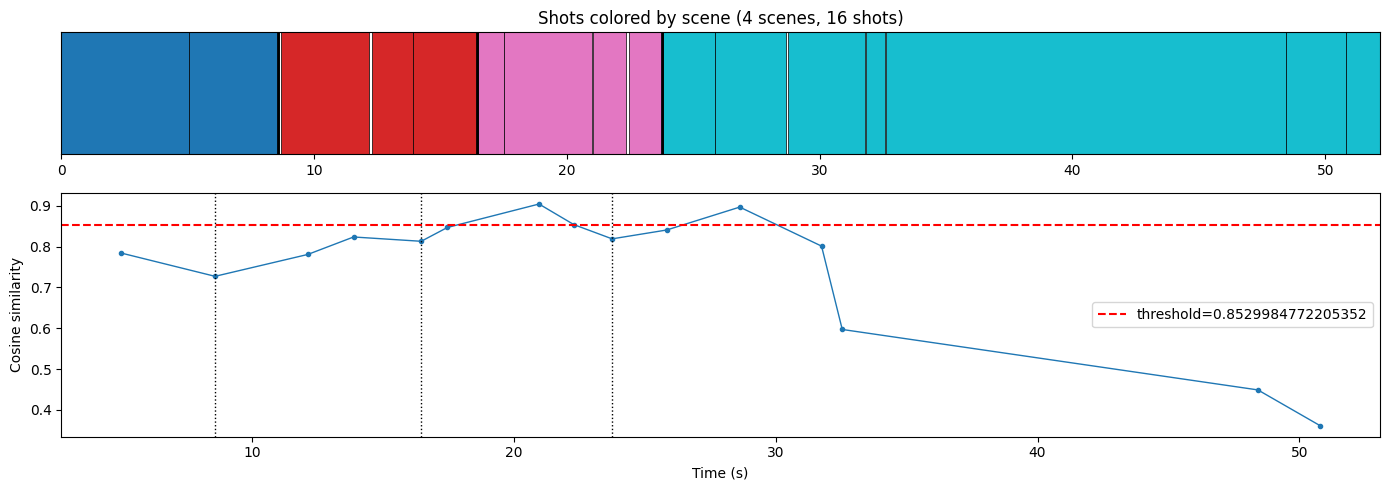

In [41]:
# ---------------------------------------------------------------------------
# 10.1 Combined shot / similarity / scene visualization
# ---------------------------------------------------------------------------
def plot_full_timeline(shots, scenes, similarities, threshold):
    fig, (ax_shots, ax_sim) = plt.subplots(
        2, 1, figsize=(14, 5), sharex=False, gridspec_kw={"height_ratios": [1, 2]}
    )

    # -- Row 1: shot rectangles, colored by scene membership --------------
    shot_to_scene = {sid: sc.scene_id for sc in scenes for sid in sc.shot_ids}
    scene_colors = plt.cm.tab10(np.linspace(0, 1, max(len(scenes), 1)))
    for shot in shots:
        color = scene_colors[shot_to_scene.get(shot.shot_id, 0) % len(scene_colors)]
        ax_shots.add_patch(Rectangle((shot.start_time, 0), shot.duration, 1, color=color, ec="black", lw=0.5))
    for scene in scenes[:-1]:
        last_shot = next(s for s in shots if s.shot_id == scene.shot_ids[-1])
        ax_shots.axvline(last_shot.end_time, color="black", lw=2)
    ax_shots.set_xlim(0, shots[-1].end_time if shots else 1)
    ax_shots.set_yticks([])
    ax_shots.set_title(f"Shots colored by scene ({len(scenes)} scenes, {len(shots)} shots)")

    # -- Row 2: similarity curve with detected scene cuts ------------------
    if len(similarities):
        x = [shots[i].end_time for i in range(len(similarities))]
        ax_sim.plot(x, similarities, marker="o", ms=3, lw=1)
        ax_sim.axhline(threshold, color="red", ls="--", label=f"threshold={threshold}")
        for scene in scenes[:-1]:
            last_shot = next(s for s in shots if s.shot_id == scene.shot_ids[-1])
            ax_sim.axvline(last_shot.end_time, color="black", lw=1, ls=":")
        ax_sim.set_xlabel("Time (s)")
        ax_sim.set_ylabel("Cosine similarity")
        ax_sim.legend()

    plt.tight_layout()
    plt.show()


plot_full_timeline(SHOTS, SCENES, SIMILARITIES, SIMILARITY_THRESHOLD)


### Summary

This notebook produced, purely from **pretrained** multimodal models:

- A shot list (`shots.csv`) from TransNetV2 (with a histogram-based fallback).
- Per-shot multimodal embeddings — visual (OpenCLIP), audio (CLAP), speech (Whisper + SentenceTransformers)
  — fused and normalized (`embeddings.npy` + `metadata.csv`).
- A transparent, threshold-based scene segmentation baseline (`scenes.json`) using consecutive-shot
  cosine similarity.

**Next steps** (out of scope for this notebook): use `embeddings.npy` + `metadata.csv` + human-labeled
scene boundaries to train a supervised scene-boundary classifier/sequence model that can replace the
fixed-threshold rule in Section 9 with a learned decision boundary.


### AI Policy
Artificial Intelligence tools (Claude, ChatGPT, Gemini) were used to assist with brainstorming, content refinement, coding support, and proofreading during this project. All AI-generated outputs were reviewed, validated, and edited by the authors. The final project reflects our own understanding, analysis, and implementation, and we accept full responsibility for its content.